# MediaPipe + LSTM Classification Model
## ADSP 32023 - Advanced Computer Vision Using Deep Learning
## Spring 2026

In [3]:
# ============================================================
# 0. Install packages
# ============================================================
!pip install -q torch torchvision torchaudio coremltools scikit-learn matplotlib pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.9 MB/s eta 0:00:00


In [4]:
# ============================================================
# 1. Imports
# ============================================================
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
from google.colab import drive

import coremltools as ct

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [6]:
# ============================================================
# 2. Paths + config
# ============================================================
drive.mount("/content/drive")
PROJECT_DIR = "/content/drive/MyDrive/UChicago/Masters/Spring/ADSP 32023/Computer Vision Final Project/"

SAVE_DIR = os.path.join(PROJECT_DIR, "data", "preprocessed")
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
GRAPH_DIR = os.path.join(PROJECT_DIR, "graphs")
RESULT_DIR = os.path.join(PROJECT_DIR, "data")
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(GRAPH_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

EXPERIMENT_NAME = "torch_lstm_coreml"
OUTPUT_MODEL_DIR = os.path.join(MODEL_DIR, EXPERIMENT_NAME)
OUTPUT_GRAPH_DIR = os.path.join(GRAPH_DIR, EXPERIMENT_NAME)
OUTPUT_RESULT_DIR = os.path.join(RESULT_DIR, EXPERIMENT_NAME)
os.makedirs(OUTPUT_MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_GRAPH_DIR, exist_ok=True)
os.makedirs(OUTPUT_RESULT_DIR, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 80
N_SPLITS = 5

HIDDEN_SIZE = 256
NUM_LAYERS = 2
DROPOUT = 0.30
LR = 1e-3
WEIGHT_DECAY = 1e-5

Mounted at /content/drive


In [7]:
# ============================================================
# 3. Load new extracted MediaPipe data
# ============================================================
X_verified = np.load(os.path.join(SAVE_DIR, "X_verified_mediapipe.npy"))
y_verified = np.load(os.path.join(SAVE_DIR, "y_verified.npy"))

X_test = np.load(os.path.join(SAVE_DIR, "X_test_mediapipe.npy"))
y_test = np.load(os.path.join(SAVE_DIR, "y_test.npy"))

kept_verified_df = pd.read_csv(os.path.join(SAVE_DIR, "kept_verified_mediapipe_dataset.csv"))
kept_test_df = pd.read_csv(os.path.join(SAVE_DIR, "kept_test_mediapipe_dataset.csv"))

with open(os.path.join(SAVE_DIR, "label_names.json"), "r") as f:
    label_names = json.load(f)

num_classes = len(label_names)
SEQUENCE_LENGTH = X_verified.shape[1]
FEATURE_SIZE = X_verified.shape[2]

print("X_verified:", X_verified.shape)
print("y_verified:", y_verified.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("SEQUENCE_LENGTH:", SEQUENCE_LENGTH)
print("FEATURE_SIZE:", FEATURE_SIZE)
print("num_classes:", num_classes)
print(label_names)

X_verified: (11897, 48, 300)
y_verified: (11897,)
X_test: (1293, 48, 300)
y_test: (1293,)
SEQUENCE_LENGTH: 48
FEATURE_SIZE: 300
num_classes: 21
['barbell biceps curl', 'bench press', 'chest fly machine', 'deadlift', 'decline bench press', 'hammer curl', 'hip thrust', 'incline bench press', 'lat pulldown', 'lateral raise', 'leg extension', 'leg raises', 'pull Up', 'push-up', 'romanian deadlift', 'russian twist', 'shoulder press', 'squat', 't bar row', 'tricep Pushdown', 'tricep dips']


In [8]:
# ============================================================
# 4. Scaling + augmentation helpers
# ============================================================
def scale_sequence_data(X_train, X_val):
    n_train, t, f = X_train.shape
    n_val = X_val.shape[0]

    scaler = StandardScaler()

    X_train_flat = X_train.reshape(-1, f)
    X_val_flat = X_val.reshape(-1, f)

    X_train_scaled = scaler.fit_transform(X_train_flat).reshape(n_train, t, f)
    X_val_scaled = scaler.transform(X_val_flat).reshape(n_val, t, f)

    return X_train_scaled.astype(np.float32), X_val_scaled.astype(np.float32), scaler


def scale_with_existing_scaler(X, scaler):
    n, t, f = X.shape
    X_flat = X.reshape(-1, f)
    X_scaled = scaler.transform(X_flat).reshape(n, t, f)
    return X_scaled.astype(np.float32)


def augment_sequence(
    seq,
    noise_std=0.015,
    scale_std=0.025,
    dropout_prob=0.06,
    time_shift_max=4,
    time_mask_prob=0.15,
    time_mask_max=5,
    feature_mask_prob=0.04
):
    aug = seq.copy()

    aug += np.random.normal(0, noise_std, size=aug.shape)
    aug *= np.random.normal(1.0, scale_std)

    shift = np.random.randint(-time_shift_max, time_shift_max + 1)
    aug = np.roll(aug, shift=shift, axis=0)

    for i in range(1, len(aug)):
        if np.random.rand() < dropout_prob:
            aug[i] = aug[i - 1]

    if np.random.rand() < time_mask_prob:
        mask_len = np.random.randint(1, time_mask_max + 1)
        start = np.random.randint(0, max(1, len(aug) - mask_len))
        replacement = aug[start - 1] if start > 0 else aug[start]
        aug[start:start + mask_len] = replacement

    feature_mask = np.random.rand(aug.shape[1]) < feature_mask_prob
    aug[:, feature_mask] = 0

    return aug.astype(np.float32)


def make_augmented_training_data(X_train, y_train, copies=2):
    X_list = [X_train]
    y_list = [y_train]

    for _ in range(copies):
        X_aug = np.array([augment_sequence(seq) for seq in X_train], dtype=np.float32)
        X_list.append(X_aug)
        y_list.append(y_train)

    return np.concatenate(X_list, axis=0), np.concatenate(y_list, axis=0)

In [9]:
# ============================================================
# 5. PyTorch LSTM + Attention model
# ============================================================
class WorkoutClassifierLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )

        self.layer_norm = nn.LayerNorm(hidden_size * 2)
        self.attention = nn.Linear(hidden_size * 2, 1)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        lstm_out = self.layer_norm(lstm_out)

        attn_scores = self.attention(lstm_out)
        attn_weights = torch.softmax(attn_scores, dim=1)

        context = torch.sum(lstm_out * attn_weights, dim=1)
        logits = self.classifier(context)

        return logits


def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(model)
    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {trainable_params:,}")

In [10]:
# ============================================================
# 6. Training helpers
# ============================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch_X, batch_y in loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)

        correct += predicted.eq(batch_y).sum().item()
        total += batch_y.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_X, batch_y in loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            total_loss += loss.item()

            _, predicted = outputs.max(1)

            correct += predicted.eq(batch_y).sum().item()
            total += batch_y.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels

In [11]:
# ============================================================
# 7. LSTM Hyperparameter Search Space
# ============================================================

HYPERPARAM_GRID = [
    {
        "hidden_size": 128,
        "num_layers": 1,
        "dropout": 0.30,
        "lr": 1e-3,
        "weight_decay": 1e-5
    },
    {
        "hidden_size": 256,
        "num_layers": 1,
        "dropout": 0.30,
        "lr": 1e-3,
        "weight_decay": 1e-5
    },
    {
        "hidden_size": 128,
        "num_layers": 2,
        "dropout": 0.35,
        "lr": 1e-3,
        "weight_decay": 1e-5
    },
    {
        "hidden_size": 256,
        "num_layers": 2,
        "dropout": 0.40,
        "lr": 5e-4,
        "weight_decay": 1e-5
    }
]

In [12]:
# ============================================================
# 8. Hyperparameter Search with GroupKFold
# ============================================================

best_all_true = None
best_all_pred = None
best_fold_accuracies = None
best_fold_macro_f1 = None
best_fold_weighted_f1 = None
best_history = None
best_fold = None

gkf = GroupKFold(n_splits=N_SPLITS)
groups = kept_verified_df["filepath"].values

search_results = []

best_config = None
best_cv_macro_f1 = -1
best_cv_accuracy = -1

for config_id, config in enumerate(HYPERPARAM_GRID, start=1):
    print("\n" + "=" * 70)
    print(f"Testing config {config_id}/{len(HYPERPARAM_GRID)}")
    print(config)
    print("=" * 70)

    fold_accuracies = []
    fold_macro_f1 = []
    fold_weighted_f1 = []

    config_all_true = []
    config_all_pred = []
    config_best_history = None
    config_best_fold = None
    config_best_acc = 0

    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(X_verified, y_verified, groups=groups),
        start=1
    ):
        print(f"\n---------- Config {config_id} | Fold {fold} ----------")

        X_train_raw = X_verified[train_idx]
        X_val_raw = X_verified[val_idx]

        y_train = y_verified[train_idx]
        y_val = y_verified[val_idx]

        X_train, X_val, scaler = scale_sequence_data(
            X_train_raw,
            X_val_raw
        )

        X_train_aug, y_train_aug = make_augmented_training_data(
            X_train,
            y_train,
            copies=2
        )

        train_dataset = TensorDataset(
            torch.FloatTensor(X_train_aug),
            torch.LongTensor(y_train_aug)
        )

        val_dataset = TensorDataset(
            torch.FloatTensor(X_val),
            torch.LongTensor(y_val)
        )

        train_loader = DataLoader(
            train_dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=2,
            pin_memory=True
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False
        )

        model = WorkoutClassifierLSTM(
            input_size=FEATURE_SIZE,
            hidden_size=config["hidden_size"],
            num_layers=config["num_layers"],
            num_classes=num_classes,
            dropout=config["dropout"]
        ).to(DEVICE)

        if config_id == 1 and fold == 1:
            count_parameters(model)

        class_weights_arr = compute_class_weight(
            class_weight="balanced",
            classes=np.unique(y_train_aug),
            y=y_train_aug
        )

        class_weights_tensor = torch.FloatTensor(
            class_weights_arr
        ).to(DEVICE)

        criterion = nn.CrossEntropyLoss(
            weight=class_weights_tensor
        )

        optimizer = optim.Adam(
            model.parameters(),
            lr=config["lr"],
            weight_decay=config["weight_decay"]
        )

        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            patience=5,
            factor=0.5
        )

        fold_best_acc = 0
        fold_best_state = None
        patience = 15
        patience_counter = 0

        history = {
            "train_loss": [],
            "val_loss": [],
            "train_acc": [],
            "val_acc": []
        }

        for epoch in range(1, EPOCHS + 1):
            train_loss, train_acc = train_one_epoch(
                model,
                train_loader,
                criterion,
                optimizer,
                DEVICE
            )

            val_loss, val_acc, val_preds, val_labels = evaluate(
                model,
                val_loader,
                criterion,
                DEVICE
            )

            scheduler.step(val_loss)

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["train_acc"].append(train_acc)
            history["val_acc"].append(val_acc)

            if val_acc > fold_best_acc:
                fold_best_acc = val_acc

                fold_best_state = {
                    k: v.cpu().clone()
                    for k, v in model.state_dict().items()
                }

                patience_counter = 0
            else:
                patience_counter += 1

            if epoch == 1 or epoch % 5 == 0:
                print(
                    f"Epoch {epoch:03d}/{EPOCHS} | "
                    f"Train Acc: {train_acc:.4f} | "
                    f"Val Acc: {val_acc:.4f} | "
                    f"Val Loss: {val_loss:.4f}"
                )

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        model.load_state_dict(fold_best_state)
        model = model.to(DEVICE)

        val_loss, val_acc, val_preds, val_labels = evaluate(
            model,
            val_loader,
            criterion,
            DEVICE
        )

        macro = f1_score(
            val_labels,
            val_preds,
            average="macro"
        )

        weighted = f1_score(
            val_labels,
            val_preds,
            average="weighted"
        )

        fold_accuracies.append(val_acc)
        fold_macro_f1.append(macro)
        fold_weighted_f1.append(weighted)

        config_all_true.extend(val_labels)
        config_all_pred.extend(val_preds)

        if val_acc > config_best_acc:
            config_best_acc = val_acc
            config_best_history = history
            config_best_fold = fold

        print(f"Fold {fold} Accuracy: {val_acc:.4f}")
        print(f"Fold {fold} Macro F1: {macro:.4f}")
        print(f"Fold {fold} Weighted F1: {weighted:.4f}")

    mean_acc = np.mean(fold_accuracies)
    mean_macro = np.mean(fold_macro_f1)
    mean_weighted = np.mean(fold_weighted_f1)

    result = {
        "config_id": config_id,
        **config,
        "mean_accuracy": mean_acc,
        "mean_macro_f1": mean_macro,
        "mean_weighted_f1": mean_weighted
    }

    search_results.append(result)

    print("\nConfig Results:")
    print(result)

    if mean_macro > best_cv_macro_f1:
        best_cv_macro_f1 = mean_macro
        best_cv_accuracy = mean_acc
        best_config = config

        best_all_true = config_all_true
        best_all_pred = config_all_pred
        best_fold_accuracies = fold_accuracies
        best_fold_macro_f1 = fold_macro_f1
        best_fold_weighted_f1 = fold_weighted_f1
        best_history = config_best_history
        best_fold = config_best_fold

print("\n================ BEST HYPERPARAMETERS ================")
print("Best config:", best_config)
print("Best mean CV macro F1:", best_cv_macro_f1)
print("Best mean CV accuracy:", best_cv_accuracy)

search_results_df = pd.DataFrame(search_results)
display(search_results_df)

SEARCH_RESULTS_PATH = os.path.join(
    OUTPUT_RESULT_DIR,
    "torch_lstm_hyperparameter_search_results.csv"
)

search_results_df.to_csv(
    SEARCH_RESULTS_PATH,
    index=False
)

print("Saved hyperparameter search results to:", SEARCH_RESULTS_PATH)


Testing config 1/4
{'hidden_size': 128, 'num_layers': 1, 'dropout': 0.3, 'lr': 0.001, 'weight_decay': 1e-05}

---------- Config 1 | Fold 1 ----------
WorkoutClassifierLSTM(
  (lstm): LSTM(300, 128, batch_first=True, bidirectional=True)
  (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (attention): Linear(in_features=256, out_features=1, bias=True)
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=21, bias=True)
  )
)
Total params: 542,486
Trainable params: 542,486
Epoch 001/80 | Train Acc: 0.8013 | Val Acc: 0.8315 | Val Loss: 0.8183
Epoch 005/80 | Train Acc: 0.9829 | Val Acc: 0.8429 | Val Loss: 1.3448
Epoch 010/80 | Train Acc: 0.9979 | Val Acc: 0.8571 | Val Loss: 1.6824
Epoch 015/80 | Train Acc: 0.9996 | Val A

,config_id,hidden_size,num_layers,dropout,lr,weight_decay,mean_accuracy,mean_macro_f1,mean_weighted_f1
0,1,128,1,0.30,0.0010,0.00001,0.869295,0.863697,0.868844
1,2,256,1,0.30,0.0010,0.00001,0.868707,0.864745,0.867941
2,3,128,2,0.35,0.0010,0.00001,0.873161,0.867978,0.872851
3,4,256,2,0.40,0.0005,0.00001,0.871228,0.867543,0.870887


Saved hyperparameter search results to: /content/drive/MyDrive/UChicago/Masters/Spring/ADSP 32023/Computer Vision Final Project/data/torch_lstm_coreml/torch_lstm_hyperparameter_search_results.csv


,fold,accuracy,macro_f1,weighted_f1
0,1,0.874370,0.870254,0.871728
1,2,0.876050,0.868433,0.876473
2,3,0.881463,0.868636,0.881579
3,4,0.847835,0.849998,0.847049
4,5,0.886087,0.882571,0.887426


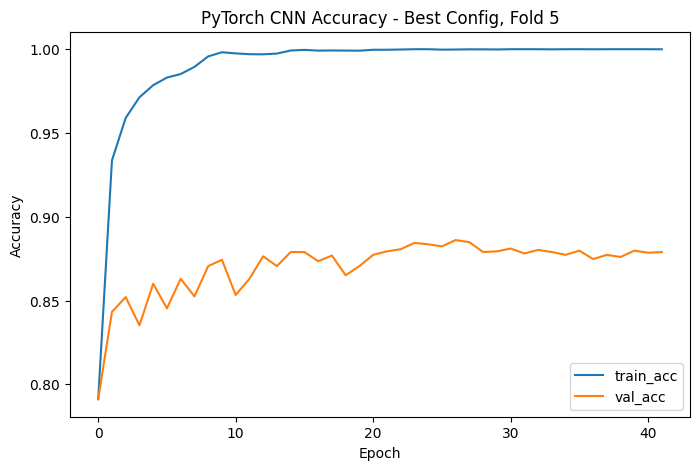

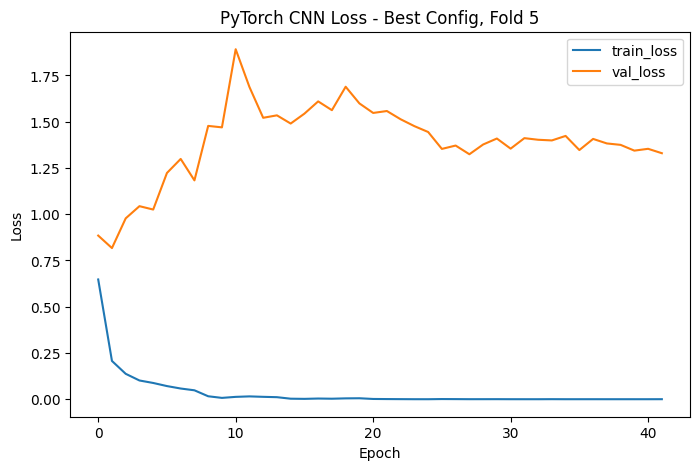

Saved: /content/drive/MyDrive/UChicago/Masters/Spring/ADSP 32023/Computer Vision Final Project/data/torch_lstm_coreml/torch_cnn_best_config_cv_results.csv
Saved: /content/drive/MyDrive/UChicago/Masters/Spring/ADSP 32023/Computer Vision Final Project/graphs/torch_lstm_coreml/torch_cnn_best_config_accuracy.png
Saved: /content/drive/MyDrive/UChicago/Masters/Spring/ADSP 32023/Computer Vision Final Project/graphs/torch_lstm_coreml/torch_cnn_best_config_loss.png


In [13]:
# ============================================================
# 9. Save best hyperparameter CV results + plots
# ============================================================

best_cv_results_df = pd.DataFrame({
    "fold": list(range(1, len(best_fold_accuracies) + 1)),
    "accuracy": best_fold_accuracies,
    "macro_f1": best_fold_macro_f1,
    "weighted_f1": best_fold_weighted_f1
})

CV_RESULTS_PATH = os.path.join(
    OUTPUT_RESULT_DIR,
    "torch_cnn_best_config_cv_results.csv"
)

best_cv_results_df.to_csv(CV_RESULTS_PATH, index=False)
display(best_cv_results_df)

plt.figure(figsize=(8, 5))
plt.plot(best_history["train_acc"], label="train_acc")
plt.plot(best_history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"PyTorch CNN Accuracy - Best Config, Fold {best_fold}")
plt.legend()

ACC_PLOT_PATH = os.path.join(
    OUTPUT_GRAPH_DIR,
    "torch_cnn_best_config_accuracy.png"
)

plt.savefig(ACC_PLOT_PATH, dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(best_history["train_loss"], label="train_loss")
plt.plot(best_history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"PyTorch CNN Loss - Best Config, Fold {best_fold}")
plt.legend()

LOSS_PLOT_PATH = os.path.join(
    OUTPUT_GRAPH_DIR,
    "torch_cnn_best_config_loss.png"
)

plt.savefig(LOSS_PLOT_PATH, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", CV_RESULTS_PATH)
print("Saved:", ACC_PLOT_PATH)
print("Saved:", LOSS_PLOT_PATH)

,precision,recall,f1-score,support
barbell biceps curl,0.743375,0.741307,0.742340,719.000000
bench press,0.682510,0.697087,0.689721,515.000000
chest fly machine,0.925750,0.931638,0.928685,629.000000
deadlift,0.850379,0.842402,0.846371,533.000000
decline bench press,0.887931,0.888889,0.888410,927.000000
hammer curl,0.795839,0.818182,0.806856,748.000000
hip thrust,0.927273,0.866038,0.895610,530.000000
incline bench press,0.869121,0.898520,0.883576,473.000000
lat pulldown,0.820106,0.828877,0.824468,374.000000
lateral raise,0.880899,0.892938,0.886878,439.000000


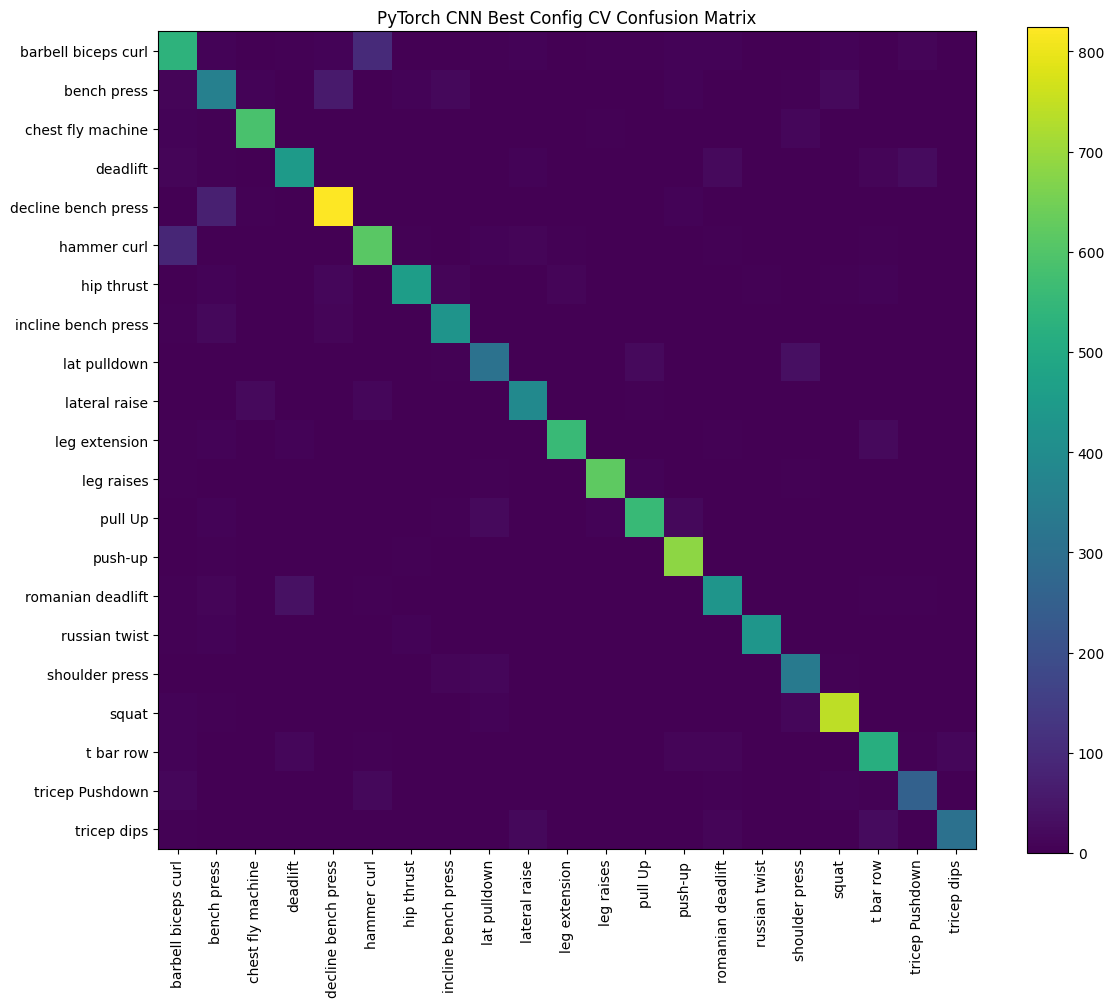

Saved: /content/drive/MyDrive/UChicago/Masters/Spring/ADSP 32023/Computer Vision Final Project/data/torch_lstm_coreml/torch_cnn_best_config_cv_classification_report.csv
Saved: /content/drive/MyDrive/UChicago/Masters/Spring/ADSP 32023/Computer Vision Final Project/graphs/torch_lstm_coreml/torch_cnn_best_config_cv_confusion_matrix.png


In [14]:
# ============================================================
# 10. Classification report + confusion matrix for best config
# ============================================================

overall_report = classification_report(
    best_all_true,
    best_all_pred,
    target_names=label_names,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(overall_report).transpose()

REPORT_PATH = os.path.join(
    OUTPUT_RESULT_DIR,
    "torch_cnn_best_config_cv_classification_report.csv"
)

report_df.to_csv(REPORT_PATH)
display(report_df)

cm = confusion_matrix(best_all_true, best_all_pred)

plt.figure(figsize=(12, 10))
plt.imshow(cm)
plt.title("PyTorch CNN Best Config CV Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(label_names)), label_names, rotation=90)
plt.yticks(range(len(label_names)), label_names)
plt.tight_layout()

CM_PNG_PATH = os.path.join(
    OUTPUT_GRAPH_DIR,
    "torch_cnn_best_config_cv_confusion_matrix.png"
)

plt.savefig(CM_PNG_PATH, dpi=200, bbox_inches="tight")
plt.show()

np.save(
    os.path.join(OUTPUT_RESULT_DIR, "torch_cnn_best_config_cv_confusion_matrix.npy"),
    cm
)

print("Saved:", REPORT_PATH)
print("Saved:", CM_PNG_PATH)

In [15]:
# ============================================================
# 11. Retrain final model on ALL verified data using best-style setup
# ============================================================
final_scaler = StandardScaler()

n, t, f = X_verified.shape
X_verified_flat = X_verified.reshape(-1, f)
X_verified_scaled = final_scaler.fit_transform(X_verified_flat).reshape(n, t, f).astype(np.float32)

X_verified_aug, y_verified_aug = make_augmented_training_data(
    X_verified_scaled,
    y_verified,
    copies=2
)

train_dataset = TensorDataset(
    torch.FloatTensor(X_verified_aug),
    torch.LongTensor(y_verified_aug)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

final_model = WorkoutClassifierLSTM(
    input_size=FEATURE_SIZE,
    hidden_size=best_config["hidden_size"],
    num_layers=best_config["num_layers"],
    num_classes=num_classes,
    dropout=best_config["dropout"]
).to(DEVICE)

class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_verified_aug),
    y=y_verified_aug
)
class_weights_tensor = torch.FloatTensor(class_weights_arr).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = optim.Adam(
    final_model.parameters(),
    lr=best_config["lr"],
    weight_decay=best_config["weight_decay"]
)

FINAL_EPOCHS = 40

final_history = {
    "train_loss": [],
    "train_acc": []
}

for epoch in range(1, FINAL_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        final_model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    final_history["train_loss"].append(train_loss)
    final_history["train_acc"].append(train_acc)

    if epoch == 1 or epoch % 5 == 0:
        print(f"Final Epoch {epoch:03d}/{FINAL_EPOCHS} | Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")

final_model.eval()

Final Epoch 001/40 | Loss: 0.6110 | Acc: 0.8047
Final Epoch 005/40 | Loss: 0.0793 | Acc: 0.9799
Final Epoch 010/40 | Loss: 0.0415 | Acc: 0.9905
Final Epoch 015/40 | Loss: 0.0325 | Acc: 0.9932
Final Epoch 020/40 | Loss: 0.0305 | Acc: 0.9941
Final Epoch 025/40 | Loss: 0.0280 | Acc: 0.9948
Final Epoch 030/40 | Loss: 0.0303 | Acc: 0.9946
Final Epoch 035/40 | Loss: 0.0196 | Acc: 0.9965
Final Epoch 040/40 | Loss: 0.0232 | Acc: 0.9955


WorkoutClassifierLSTM(
  (lstm): LSTM(300, 128, num_layers=2, batch_first=True, dropout=0.35, bidirectional=True)
  (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (attention): Linear(in_features=256, out_features=1, bias=True)
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.35, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.35, inplace=False)
    (6): Linear(in_features=128, out_features=21, bias=True)
  )
)

In [28]:
# ============================================================
# 12. Evaluate final model on official test split
# ============================================================

final_model = final_model.to(DEVICE)
final_model.eval()

X_test_scaled = scale_with_existing_scaler(
    X_test,
    final_scaler
)

test_loader = DataLoader(
    TensorDataset(
        torch.FloatTensor(X_test_scaled),
        torch.LongTensor(y_test)
    ),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loss, test_acc, test_preds, test_labels = evaluate(
    final_model,
    test_loader,
    criterion,
    DEVICE
)

test_macro = f1_score(
    test_labels,
    test_preds,
    average="macro"
)

test_weighted = f1_score(
    test_labels,
    test_preds,
    average="weighted"
)

print("\n================ Official Test Results ================")
print("Official Test Loss:", round(test_loss, 4))
print("Official Test Accuracy:", round(test_acc, 4))
print("Official Test Macro F1:", round(test_macro, 4))
print("Official Test Weighted F1:", round(test_weighted, 4))

print("\n================ Classification Report ================")

print(classification_report(
    test_labels,
    test_preds,
    target_names=label_names,
    zero_division=0
))


================ Official Test Results ================
Official Test Loss: 5.372
Official Test Accuracy: 0.594
Official Test Macro F1: 0.5676
Official Test Weighted F1: 0.58

================ Classification Report ================
                     precision    recall  f1-score   support

barbell biceps curl       0.33      0.80      0.47        49
        bench press       0.24      0.69      0.35        36
  chest fly machine       0.67      0.69      0.68        89
           deadlift       0.69      0.66      0.68       156
decline bench press       0.37      0.28      0.32        83
        hammer curl       0.00      0.00      0.00        49
         hip thrust       0.64      0.81      0.72        70
incline bench press       0.00      0.00      0.00        77
       lat pulldown       0.80      0.35      0.49        34
      lateral raise       0.65      0.65      0.65        26
      leg extension       0.56      0.97      0.71        36
         leg raises       0.89    

,precision,recall,f1-score,support
barbell biceps curl,0.333333,0.795918,0.469880,49.000000
bench press,0.235849,0.694444,0.352113,36.000000
chest fly machine,0.670330,0.685393,0.677778,89.000000
deadlift,0.691275,0.660256,0.675410,156.000000
decline bench press,0.370968,0.277108,0.317241,83.000000
hammer curl,0.000000,0.000000,0.000000,49.000000
hip thrust,0.640449,0.814286,0.716981,70.000000
incline bench press,0.000000,0.000000,0.000000,77.000000
lat pulldown,0.800000,0.352941,0.489796,34.000000
lateral raise,0.653846,0.653846,0.653846,26.000000


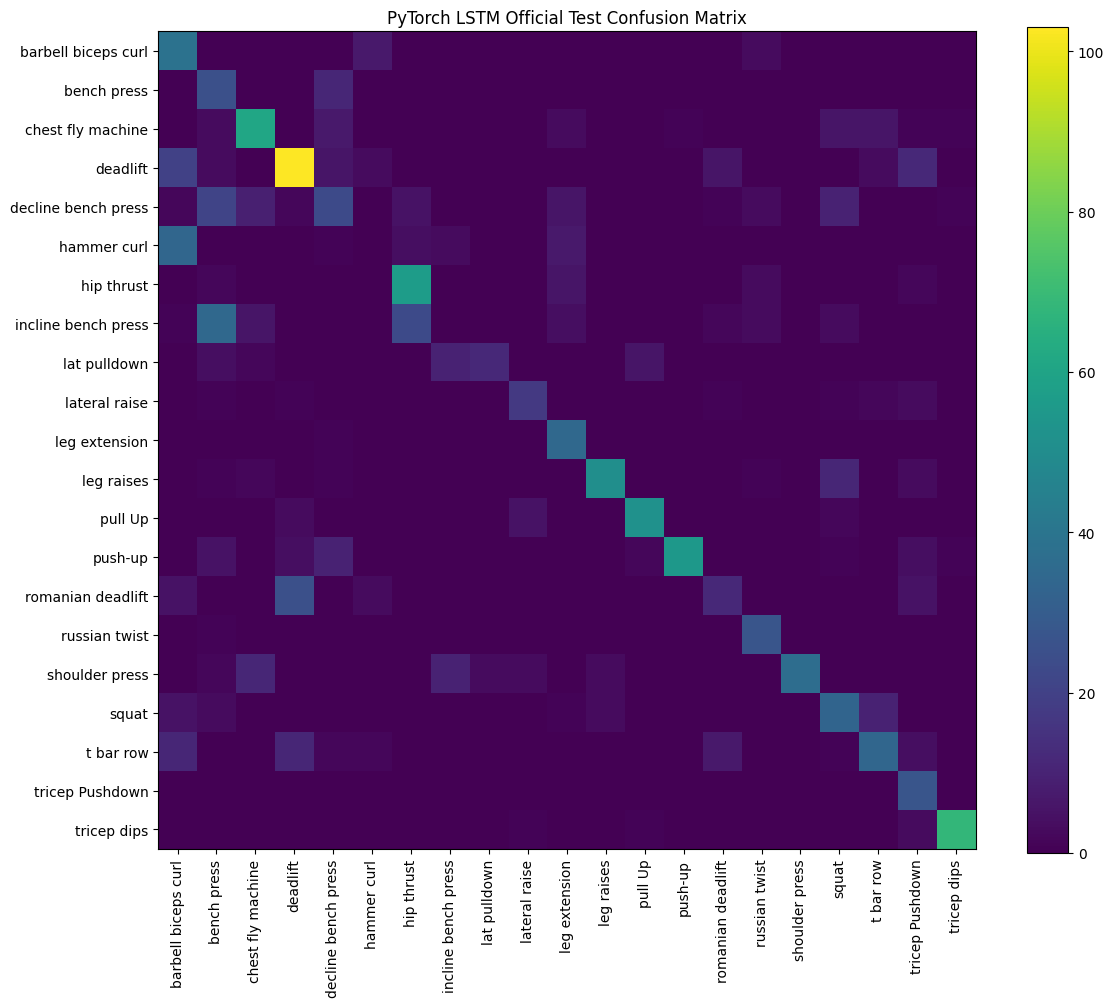

In [22]:
# ============================================================
# 13. Save final test report + confusion matrix
# ============================================================
test_report = classification_report(
    test_labels,
    test_preds,
    target_names=label_names,
    zero_division=0,
    output_dict=True
)

test_report_df = pd.DataFrame(test_report).transpose()

TEST_REPORT_PATH = os.path.join(OUTPUT_RESULT_DIR, "torch_lstm_official_test_report.csv")
test_report_df.to_csv(TEST_REPORT_PATH)
display(test_report_df)

test_cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(12, 10))
plt.imshow(test_cm)
plt.title("PyTorch LSTM Official Test Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(label_names)), label_names, rotation=90)
plt.yticks(range(len(label_names)), label_names)
plt.tight_layout()

TEST_CM_PATH = os.path.join(OUTPUT_GRAPH_DIR, "torch_lstm_official_test_confusion_matrix.png")
plt.savefig(TEST_CM_PATH, dpi=200, bbox_inches="tight")
plt.show()

np.save(os.path.join(OUTPUT_RESULT_DIR, "torch_lstm_official_test_confusion_matrix.npy"), test_cm)

In [23]:
# ============================================================
# 14. Save PyTorch checkpoint + scaler + labels
# ============================================================

final_model_cpu = final_model.cpu()

CHECKPOINT_PATH = os.path.join(
    OUTPUT_MODEL_DIR,
    "best_workout_lstm_model.pth"
)

checkpoint = {
    "model_state_dict": final_model_cpu.state_dict(),
    "hyperparams": {
        "input_size": FEATURE_SIZE,
        "hidden_size": best_config["hidden_size"],
        "num_layers": best_config["num_layers"],
        "num_classes": num_classes,
        "dropout": best_config["dropout"],
        "sequence_length": SEQUENCE_LENGTH,
        "lr": best_config["lr"],
        "weight_decay": best_config["weight_decay"]
    },
    "best_config": best_config,
    "label_names": label_names,
    "test_accuracy": test_acc,
    "test_macro_f1": test_macro,
    "test_weighted_f1": test_weighted
}

torch.save(checkpoint, CHECKPOINT_PATH)

SCALER_JSON_PATH = os.path.join(
    OUTPUT_MODEL_DIR,
    "mediapipe_scaler.json"
)

with open(SCALER_JSON_PATH, "w") as f:
    json.dump({
        "mean": final_scaler.mean_.tolist(),
        "scale": final_scaler.scale_.tolist()
    }, f)

LABEL_PATH = os.path.join(
    OUTPUT_MODEL_DIR,
    "label_names.json"
)

with open(LABEL_PATH, "w") as f:
    json.dump(label_names, f)

print("Saved checkpoint:", CHECKPOINT_PATH)
print("Saved scaler:", SCALER_JSON_PATH)
print("Saved labels:", LABEL_PATH)

Saved checkpoint: /content/drive/MyDrive/UChicago/Masters/Spring/ADSP 32023/Computer Vision Final Project/models/torch_lstm_coreml/best_workout_lstm_model.pth
Saved scaler: /content/drive/MyDrive/UChicago/Masters/Spring/ADSP 32023/Computer Vision Final Project/models/torch_lstm_coreml/mediapipe_scaler.json
Saved labels: /content/drive/MyDrive/UChicago/Masters/Spring/ADSP 32023/Computer Vision Final Project/models/torch_lstm_coreml/label_names.json


In [20]:
# ============================================================
# 15. Convert final PyTorch model to CoreML
# ============================================================

export_model = WorkoutClassifierLSTM(
    input_size=FEATURE_SIZE,
    hidden_size=checkpoint["hyperparams"]["hidden_size"],
    num_layers=checkpoint["hyperparams"]["num_layers"],
    num_classes=num_classes,
    dropout=checkpoint["hyperparams"]["dropout"]
)

export_model.load_state_dict(checkpoint["model_state_dict"])
export_model.eval()

example_input = torch.rand(
    1,
    SEQUENCE_LENGTH,
    FEATURE_SIZE
)

with torch.no_grad():
    example_output = export_model(example_input)

print("Example input:", example_input.shape)
print("Example output:", example_output.shape)

traced_model = torch.jit.trace(
    export_model,
    example_input
)

coreml_model = ct.convert(
    traced_model,
    inputs=[
        ct.TensorType(
            name="input",
            shape=example_input.shape
        )
    ],
    outputs=[
        ct.TensorType(name="logits")
    ],
    convert_to="mlprogram",
    minimum_deployment_target=ct.target.iOS15
)

COREML_PATH = os.path.join(
    OUTPUT_MODEL_DIR,
    "WorkoutClassifierLSTM.mlpackage"
)

coreml_model.save(COREML_PATH)

print("Saved CoreML model:", COREML_PATH)

Example input: torch.Size([1, 48, 300])
Example output: torch.Size([1, 21])


Running MIL backend_mlprogram pipeline: 100%|██████████| 12/12 [00:00<00:00, 974.10 passes/s]


Saved CoreML model: /content/drive/MyDrive/UChicago/Masters/Spring/ADSP 32023/Computer Vision Final Project/models/torch_lstm_coreml/WorkoutClassifierLSTM.mlpackage
